# Exploratory Data Analysis (EDA)
**Project:** Bayesian Regime Detection via Gibbs Sampling  
**Authors:** Bandaru Jaya Akshitha · Budati Nagaveni · Soumya Pandey  
**Datasets:** S&P 500 (US) · NIFTY 50 (India) · US GDP · US Recession Indicator

---
### Table of Contents
1. Data Loading & Shape
2. Missing Values
3. Descriptive Statistics
4. Historical Price Trends
5. Log Return Time Series
6. Return Distributions (Histogram + KDE)
7. Q–Q Plots (Normality Check)
8. Rolling Volatility (21-Week Window)
9. Autocorrelation (ACF) of Returns & Squared Returns
10. Correlation Between Markets
11. Regime Context: NBER Recessions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# ── Styling ───────────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (14, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RECESSION_COLOR = "#e74c3c"
SP_COLOR        = "#3498db"
NIF_COLOR       = "#2ecc71"


In [2]:
# ── Load ─────────────────────────────────────────────────────────────────────
sp500 = pd.read_csv("sp500_data.csv", index_col="Date")
nifty = pd.read_csv("nifty50_data.csv", index_col="Date")
rec   = pd.read_csv("us_recession.csv", index_col="observation_date")

# Strip timezone from equity indices
sp500.index = pd.to_datetime(sp500.index, utc=True).tz_localize(None)
nifty.index = pd.to_datetime(nifty.index, utc=True).tz_localize(None)
rec.index   = pd.to_datetime(rec.index)

print("S&P 500  :", sp500.shape,  "| Date range:", sp500.index.min().date(), "→", sp500.index.max().date())
print("NIFTY 50 :", nifty.shape, "| Date range:", nifty.index.min().date(), "→", nifty.index.max().date())
print("Recession:", rec.shape,   "| Date range:", rec.index.min().date(),   "→", rec.index.max().date())


S&P 500  : (1111, 6) | Date range: 2005-01-01 → 2026-04-11
NIFTY 50 : (970, 6) | Date range: 2007-09-16 → 2026-04-12
Recession: (2056, 1) | Date range: 1854-12-01 → 2026-03-01


## 2. Missing Values

In [3]:
print("=== Missing Values ===")
print("\n[S&P 500]\n", sp500.isnull().sum())
print("\n[NIFTY 50]\n", nifty.isnull().sum())

# Drop NaN log returns
sp500.dropna(subset=["Log_Return"], inplace=True)
nifty.dropna(subset=["Log_Return"],  inplace=True)
print("\nAfter drop — SP500:", len(sp500), "  NIFTY:", len(nifty))


=== Missing Values ===

[S&P 500]
 Open          0
High          0
Low           0
Close         0
Volume        0
Log_Return    1
dtype: int64

[NIFTY 50]
 Open          0
High          0
Low           0
Close         0
Volume        0
Log_Return    1
dtype: int64

After drop — SP500: 1110   NIFTY: 969


## 3. Descriptive Statistics

In [4]:
stats_df = pd.DataFrame({
    "S&P 500 Returns" : sp500["Log_Return"],
    "NIFTY 50 Returns": nifty["Log_Return"],
}).describe().T

# Add extras
for name, col in [("S&P 500 Returns", sp500["Log_Return"]),
                  ("NIFTY 50 Returns", nifty["Log_Return"])]:
    stats_df.loc[name, "skewness"] = col.skew()
    stats_df.loc[name, "kurtosis"] = col.kurtosis()

stats_df = stats_df[["count","mean","std","min","25%","50%","75%","max","skewness","kurtosis"]]
stats_df = stats_df.round(6)
display(stats_df)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
S&P 500 Returns,1110.0,0.001615,0.024421,-0.200838,-0.009655,0.002835,0.014588,0.114237,-0.943546,8.410627
NIFTY 50 Returns,969.0,0.001668,0.027101,-0.173755,-0.012355,0.003314,0.015889,0.143568,-0.441884,5.049266


## 4. Historical Price Trends

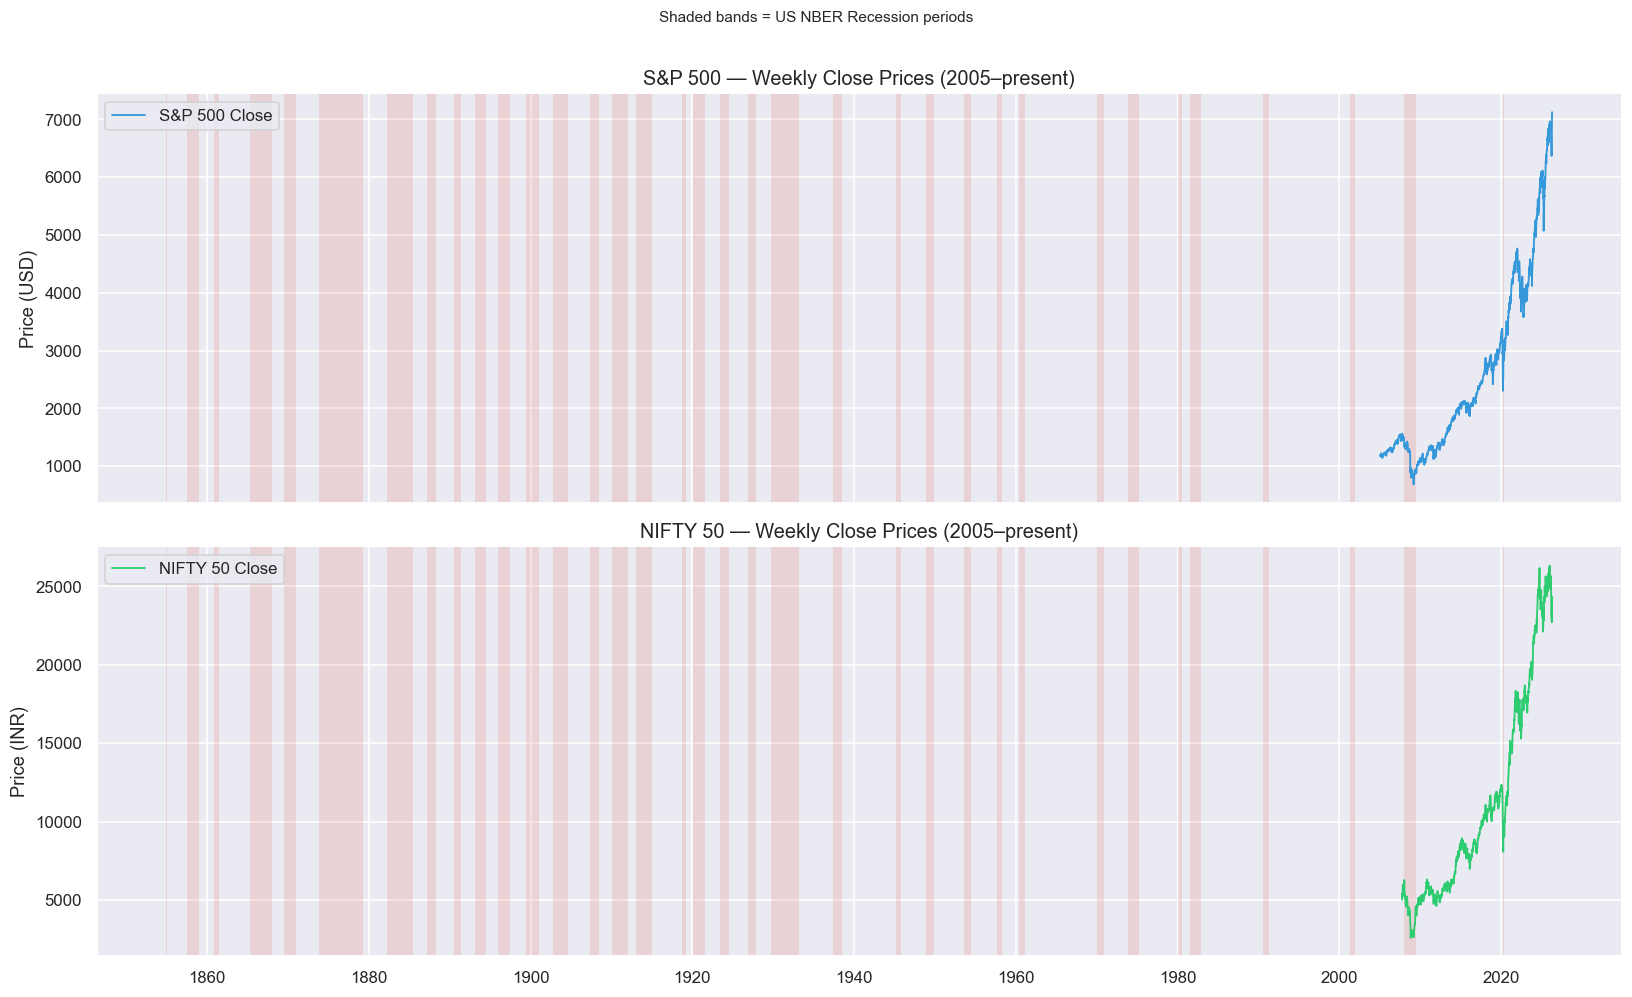

In [5]:
def shade_recessions(ax, df_rec, y0=None, y1=None):
    rec_mask = df_rec["USREC"] == 1
    in_rec   = False
    start    = None
    for date, val in rec_mask.items():
        if val and not in_rec:
            start  = date
            in_rec = True
        elif not val and in_rec:
            ax.axvspan(start, date, color=RECESSION_COLOR, alpha=0.15, lw=0)
            in_rec = False
    if in_rec:
        ax.axvspan(start, df_rec.index[-1], color=RECESSION_COLOR, alpha=0.15, lw=0)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(sp500.index, sp500["Close"], color=SP_COLOR, lw=1.2, label="S&P 500 Close")
axes[0].set_title("S&P 500 — Weekly Close Prices (2005–present)", fontsize=13)
axes[0].set_ylabel("Price (USD)")
shade_recessions(axes[0], rec)
axes[0].legend(loc="upper left")

axes[1].plot(nifty.index, nifty["Close"], color=NIF_COLOR, lw=1.2, label="NIFTY 50 Close")
axes[1].set_title("NIFTY 50 — Weekly Close Prices (2005–present)", fontsize=13)
axes[1].set_ylabel("Price (INR)")
shade_recessions(axes[1], rec)
axes[1].legend(loc="upper left")

plt.suptitle("Shaded bands = US NBER Recession periods", fontsize=10, y=1.005)
plt.tight_layout()
plt.show()


## 5. Log Return Time Series

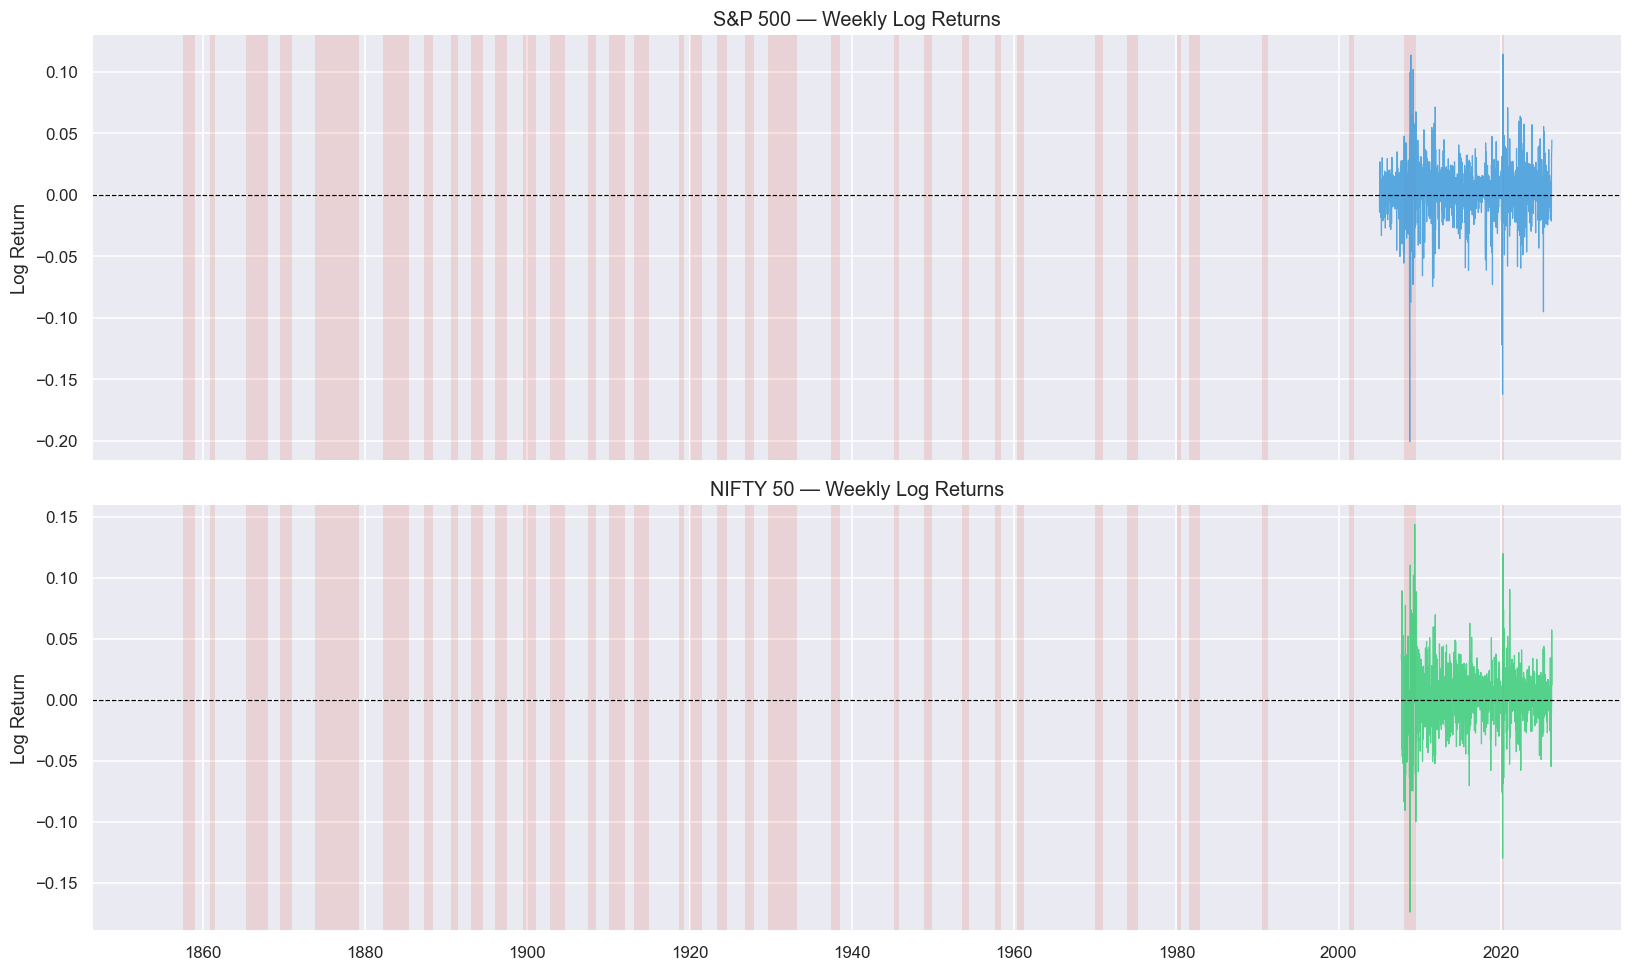

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(sp500.index, sp500["Log_Return"], color=SP_COLOR, lw=0.8, alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].set_title("S&P 500 — Weekly Log Returns", fontsize=13)
axes[0].set_ylabel("Log Return")
shade_recessions(axes[0], rec)

axes[1].plot(nifty.index, nifty["Log_Return"], color=NIF_COLOR, lw=0.8, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
axes[1].set_title("NIFTY 50 — Weekly Log Returns", fontsize=13)
axes[1].set_ylabel("Log Return")
shade_recessions(axes[1], rec)

plt.tight_layout()
plt.show()


## 6. Return Distributions

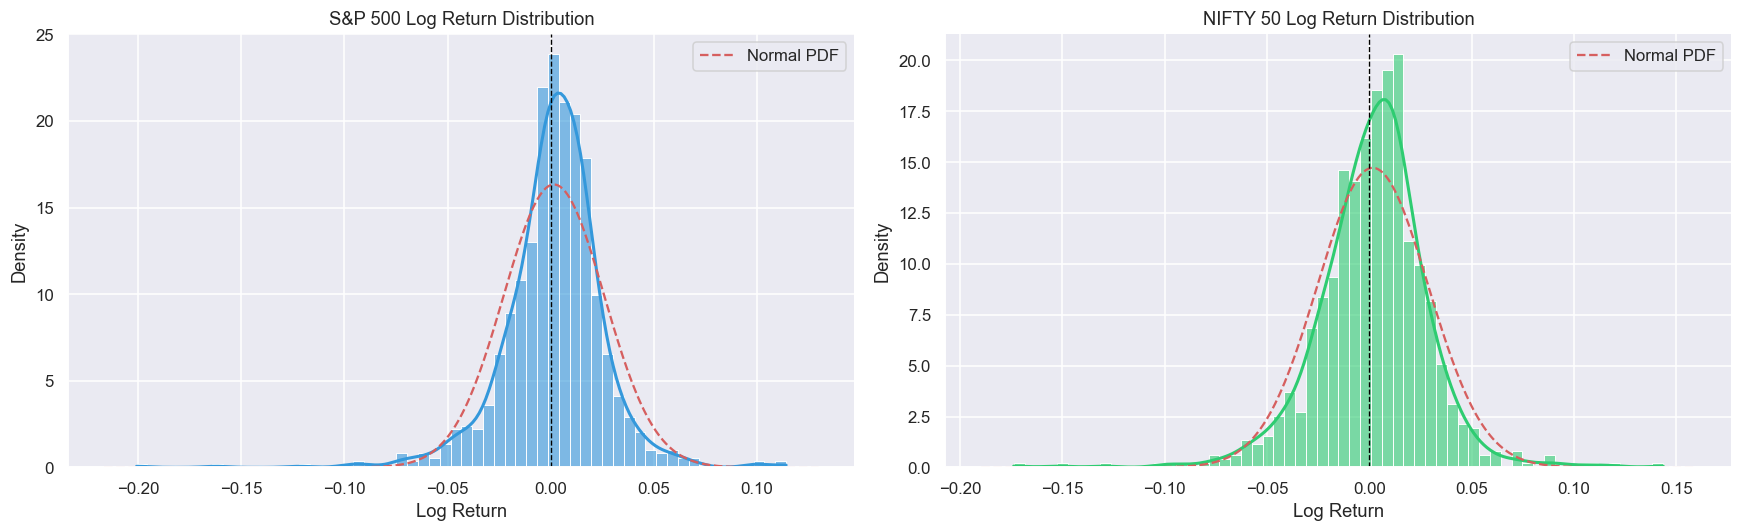

Heavy tails?
  S&P 500: excess kurtosis = 8.411 (fat tails)
  NIFTY 50: excess kurtosis = 5.049 (fat tails)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, name, color in [
        (axes[0], sp500["Log_Return"], "S&P 500", SP_COLOR),
        (axes[1], nifty["Log_Return"],  "NIFTY 50", NIF_COLOR)]:
    sns.histplot(col, bins=60, kde=True, ax=ax, color=color,
                 line_kws={"lw": 2}, stat="density", alpha=0.6)
    xmin, xmax = ax.get_xlim()
    xs = np.linspace(xmin, xmax, 300)
    ax.plot(xs, stats.norm.pdf(xs, col.mean(), col.std()),
            "r--", lw=1.5, label="Normal PDF")
    ax.axvline(0, color="black", lw=0.9, linestyle="--")
    ax.set_title(f"{name} Log Return Distribution", fontsize=12)
    ax.set_xlabel("Log Return")
    ax.legend()

plt.tight_layout()
plt.show()

print("Heavy tails?")
for name, col in [("S&P 500", sp500["Log_Return"]),("NIFTY 50", nifty["Log_Return"])]:
    ku = col.kurtosis()
    print(f"  {name}: excess kurtosis = {ku:.3f} ({'fat tails' if ku > 0 else 'thin tails'})")


## 7. Q–Q Plots (Normality Check)

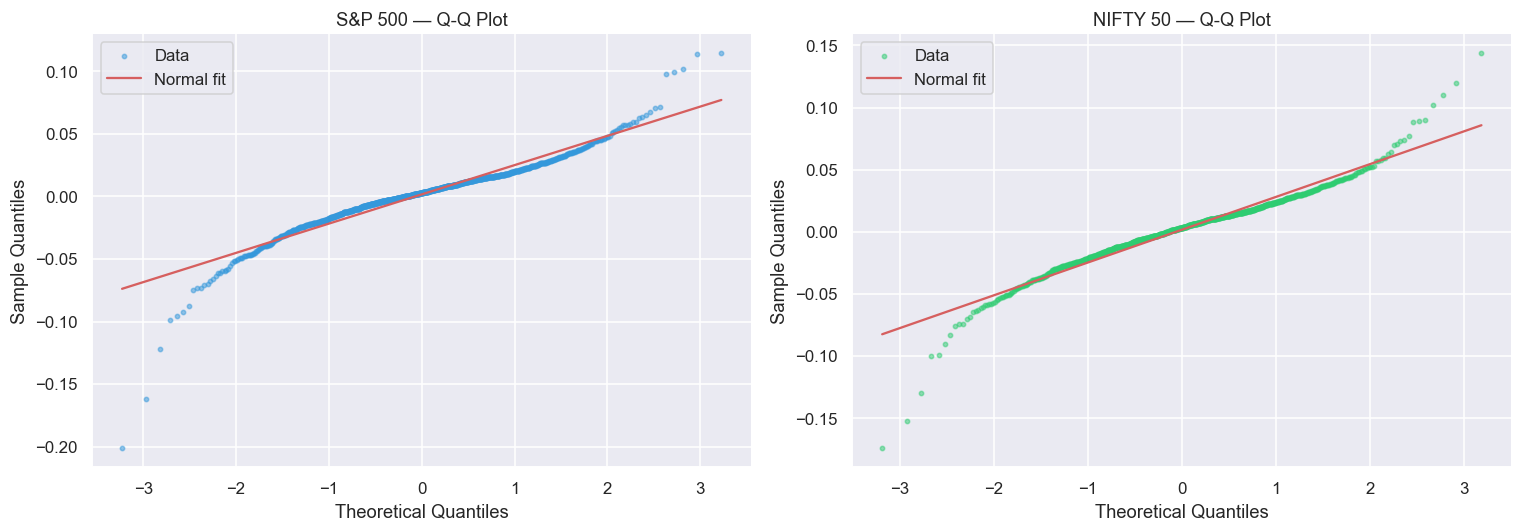

Deviation from the diagonal in the tails → heavy tails / fat tails.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, name, color in [
        (axes[0], sp500["Log_Return"], "S&P 500",  SP_COLOR),
        (axes[1], nifty["Log_Return"],  "NIFTY 50", NIF_COLOR)]:
    (osm, osr), (slope, intercept, _) = stats.probplot(col)
    ax.scatter(osm, osr, s=8, alpha=0.5, color=color, label="Data")
    ax.plot(osm, slope * np.array(osm) + intercept, "r-", lw=1.5, label="Normal fit")
    ax.set_title(f"{name} — Q-Q Plot", fontsize=12)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.legend()

plt.tight_layout()
plt.show()
print("Deviation from the diagonal in the tails → heavy tails / fat tails.")


## 8. Rolling Volatility (21-Week Window)

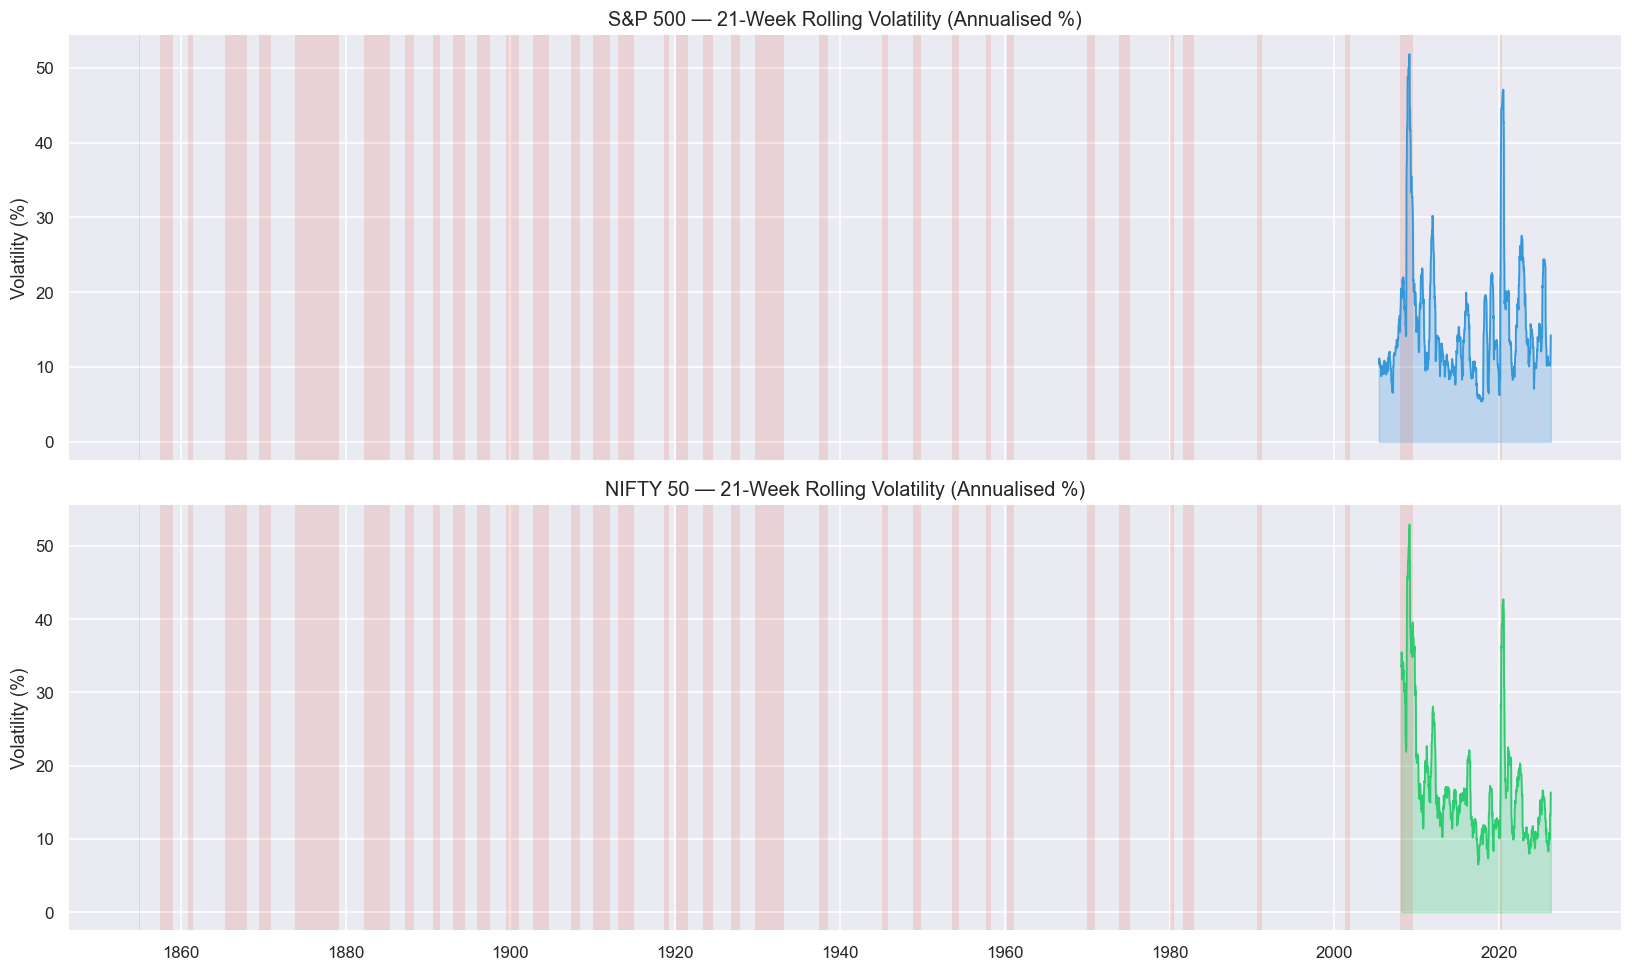

In [9]:
WINDOW = 21  # ≈ 5 months

sp500["RollingVol"] = sp500["Log_Return"].rolling(WINDOW).std() * np.sqrt(52) * 100  # annualised %
nifty["RollingVol"]  = nifty["Log_Return"].rolling(WINDOW).std()  * np.sqrt(52) * 100

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(sp500.index, sp500["RollingVol"], color=SP_COLOR, lw=1.2)
axes[0].fill_between(sp500.index, 0, sp500["RollingVol"], color=SP_COLOR, alpha=0.25)
axes[0].set_title("S&P 500 — 21-Week Rolling Volatility (Annualised %)", fontsize=13)
axes[0].set_ylabel("Volatility (%)")
shade_recessions(axes[0], rec)

axes[1].plot(nifty.index, nifty["RollingVol"], color=NIF_COLOR, lw=1.2)
axes[1].fill_between(nifty.index, 0, nifty["RollingVol"], color=NIF_COLOR, alpha=0.25)
axes[1].set_title("NIFTY 50 — 21-Week Rolling Volatility (Annualised %)", fontsize=13)
axes[1].set_ylabel("Volatility (%)")
shade_recessions(axes[1], rec)

plt.tight_layout()
plt.show()


## 9. Autocorrelation (ACF) of Returns & Squared Returns

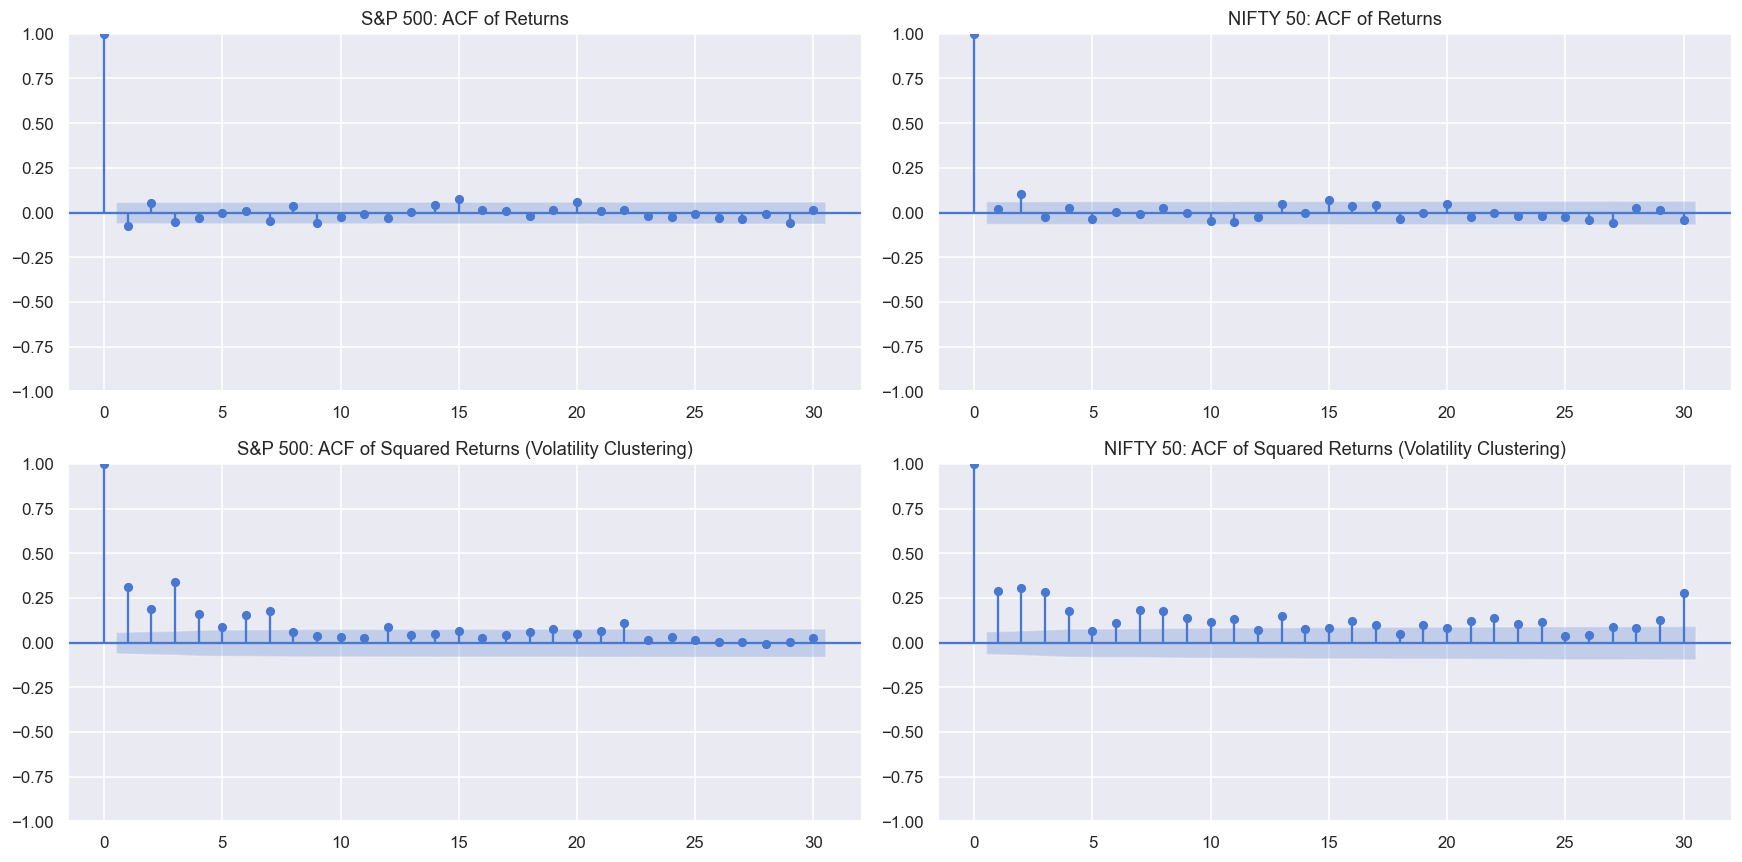

Near-zero ACF in returns but significant ACF in squared returns → volatility clustering.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for col_idx, (df, name) in enumerate([(sp500, "S&P 500"), (nifty, "NIFTY 50")]):
    plot_acf(df["Log_Return"],         lags=30, ax=axes[0][col_idx], title=f"{name}: ACF of Returns")
    plot_acf(df["Log_Return"]**2,      lags=30, ax=axes[1][col_idx], title=f"{name}: ACF of Squared Returns (Volatility Clustering)")

plt.tight_layout()
plt.show()
print("Near-zero ACF in returns but significant ACF in squared returns → volatility clustering.")


## 10. Correlation Between Markets

Pearson Correlation: nan


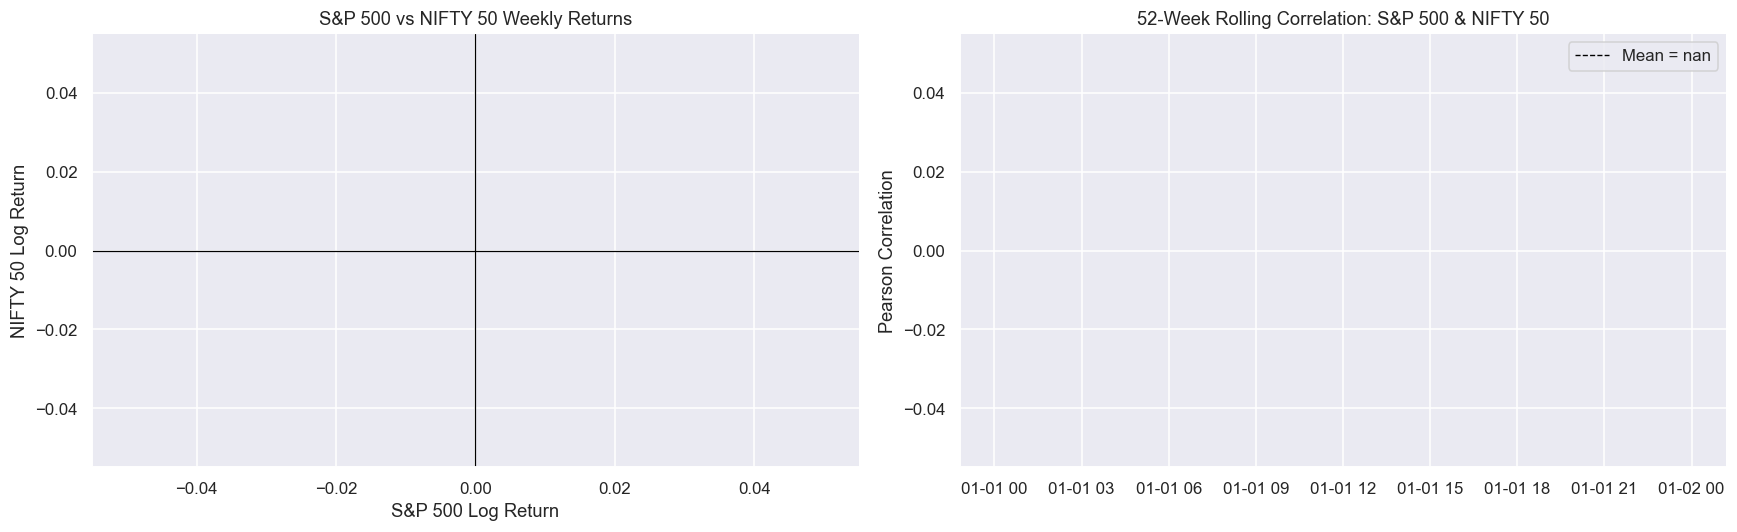

In [11]:
combined = pd.DataFrame({
    "S&P 500": sp500["Log_Return"],
    "NIFTY 50": nifty["Log_Return"],
}).dropna()

print("Pearson Correlation:", combined.corr().loc["S&P 500", "NIFTY 50"].round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter
axes[0].scatter(combined["S&P 500"], combined["NIFTY 50"],
                alpha=0.4, s=18, color="mediumpurple")
axes[0].axhline(0, color="black", lw=0.8); axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("S&P 500 Log Return"); axes[0].set_ylabel("NIFTY 50 Log Return")
axes[0].set_title("S&P 500 vs NIFTY 50 Weekly Returns")

# Heatmap (rolling 52-week corr)
rolling_corr = combined["S&P 500"].rolling(52).corr(combined["NIFTY 50"])
axes[1].plot(rolling_corr.index, rolling_corr, color="mediumpurple", lw=1.3)
axes[1].axhline(rolling_corr.mean(), color="black", lw=0.9, linestyle="--",
                label=f"Mean = {rolling_corr.mean():.3f}")
axes[1].set_title("52-Week Rolling Correlation: S&P 500 & NIFTY 50")
axes[1].set_ylabel("Pearson Correlation"); axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Extreme Returns During NBER Recessions

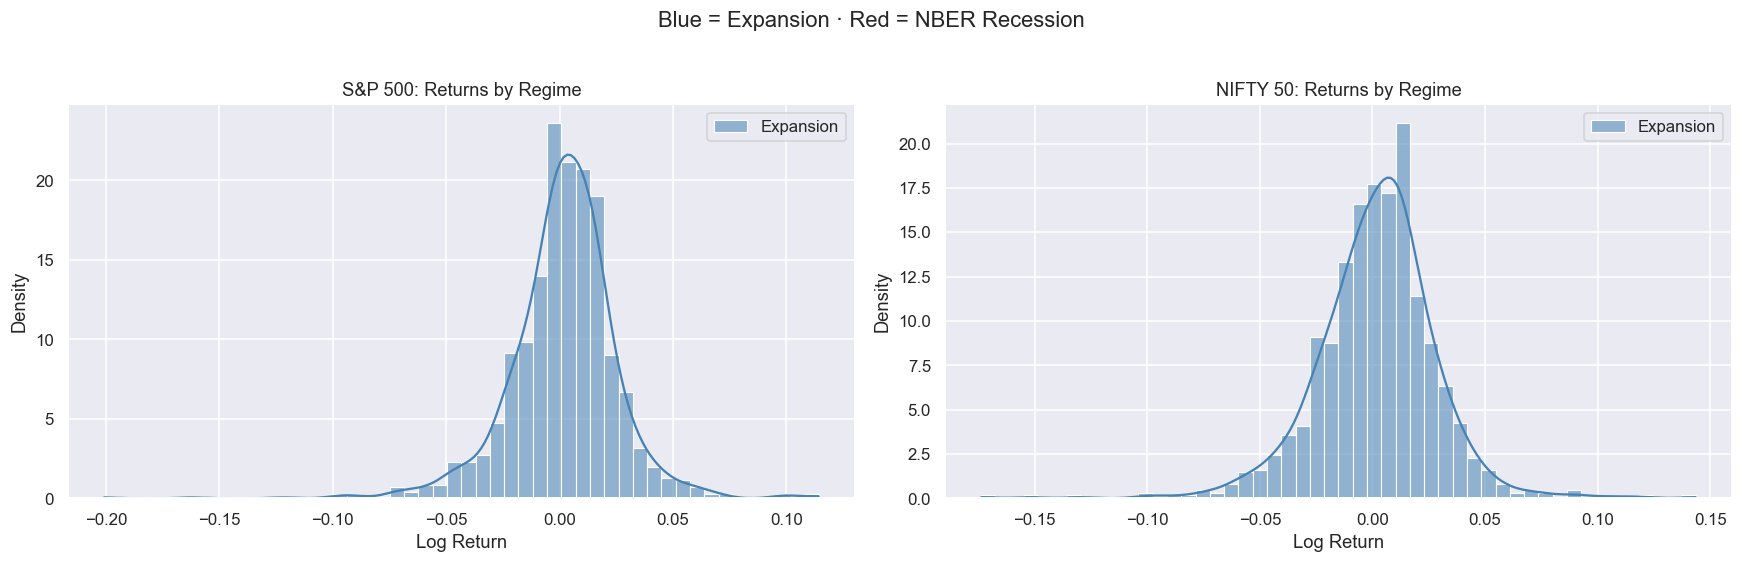


Summary by regime (S&P 500):
        Expansion  Recession
count  1110.00000        0.0
mean      0.00162        NaN
std       0.02442        NaN
min      -0.20084        NaN
25%      -0.00966        NaN
50%       0.00283        NaN
75%       0.01459        NaN
max       0.11424        NaN

Summary by regime (NIFTY 50):
       Expansion  Recession
count  969.00000        0.0
mean     0.00167        NaN
std      0.02710        NaN
min     -0.17375        NaN
25%     -0.01235        NaN
50%      0.00331        NaN
75%      0.01589        NaN
max      0.14357        NaN


In [12]:
rec_weekly = rec.resample("W").ffill()

sp_aligned = sp500["Log_Return"].to_frame().join(rec_weekly, how="left").fillna(0)
ni_aligned  = nifty["Log_Return"].to_frame().join(rec_weekly, how="left").fillna(0)

sp_bull = sp_aligned.loc[sp_aligned["USREC"] == 0, "Log_Return"]
sp_bear = sp_aligned.loc[sp_aligned["USREC"] == 1, "Log_Return"]
ni_bull  = ni_aligned.loc[ni_aligned["USREC"] == 0, "Log_Return"]
ni_bear  = ni_aligned.loc[ni_aligned["USREC"] == 1, "Log_Return"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, bull, bear, name in [
        (axes[0], sp_bull, sp_bear, "S&P 500"),
        (axes[1], ni_bull, ni_bear, "NIFTY 50")]:
    sns.histplot(bull, bins=50, kde=True, ax=ax, color="steelblue",
                 label="Expansion", stat="density", alpha=0.55)
    sns.histplot(bear, bins=50, kde=True, ax=ax, color=RECESSION_COLOR,
                 label="Recession", stat="density", alpha=0.55)
    ax.set_title(f"{name}: Returns by Regime")
    ax.set_xlabel("Log Return")
    ax.legend()

plt.suptitle("Blue = Expansion · Red = NBER Recession", y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary by regime (S&P 500):")
print(pd.DataFrame({"Expansion": sp_bull.describe(), "Recession": sp_bear.describe()}).round(5))
print("\nSummary by regime (NIFTY 50):")
print(pd.DataFrame({"Expansion": ni_bull.describe(), "Recession": ni_bear.describe()}).round(5))
